# Titanic Dataset — Exploratory Data Analysis

## Project Overview

This project performs an exploratory data analysis (EDA) on the Titanic dataset.
The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn to inspect,
clean, transform, visualize, and analyze the dataset.

The main objective is to understand the factors associated with passenger survival
and explore relationships between variables such as passenger class, sex, age,
fare, and family size.

The dataset contains information about 891 Titanic passengers and includes both
numerical and categorical variables.

#Step 1: Choose Your Dataset

## Dataset Source

Dataset: Titanic Dataset

Source: Kaggle Titanic Dataset

The dataset contains passenger information including survival status, passenger
class, sex, age, family information, ticket, fare, cabin, and port of embarkation.

INSTALL ALL THE LIBRARIES FIRST USING PIP INSTALL:

In [2]:
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install seaborn

~pandas used for:

1.reading CSV,
2.DataFrames,
3.cleaning data,
4.filtering,
5sorting,
6.grouping.

~numpy: used for numerical operations.

~matplotlib: used for creating charts.

~seaborn: used for statistical visualizations.


IMPORT ALL THE LIBRARIES:

In [3]:
import matplotlib.pylab as plt
import pandas as pd
import numpy as np
import seaborn as sns


UPLOAD DATA SET ON COLAB AND READ CSV FILE:

In [6]:
df=pd.read_csv("Titanic-Dataset.csv")

#Step 2: Load, Inspect &amp; Plan Your Approach
PERFORM BASIC OPERATIONS:

In [9]:
print("Shape of Titanic dataset:",df.shape)   # Shows the number of rows and columns in the DataFrame
print("----------------------------------------------------------")
print(df.head())  # Shows the first 5 rows of the DataFrame
print("----------------------------------------------------------")
print(df.tail())   # Shows the last 5 rows of the DataFrame
print("----------------------------------------------------------")
print(df.info())  # Shows DataFrame information, including columns, data types, and non-null values
print("----------------------------------------------------------")
print(df.describe())  # Shows statistical summary of numerical columns
print("----------------------------------------------------------")

Shape of Titanic dataset: (891, 12)
----------------------------------------------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0     

Numerical columns contain values such as integers and decimal numbers, while categorical columns contain text or object-type data.

NUMERICAL DATA:
PassengerId,
Survived,
Pclass,
Age,
SibSp,
Parch,
Fare.

CATEGORICAL DATA: Name, Sex, Ticket, Cabin, and Embarked.

## Research Questions

The following questions will guide the exploratory data analysis:

1. Did passenger sex affect survival rates?
2. Did passenger class affect survival and fare?
3. How are age, fare, and other numerical variables related to each other?

#Step 3: Clean, Transform & Explore

In [10]:
#missing values
print(df.isna().sum())#isna gives value in true/false, sum actually gives numbers

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Understand the missing values
We have:

1.Age

177 missing values.

We should NOT simply delete 177 passengers because that would remove a significant portion of the dataset.
Instead, we'll replace missing ages with the median.

2.Embarked
Only 2 values are missing.
We'll replace them with the most common embarkation port.

3.Cabin

687 values are missing.
That's a very large amount of missing data.
For this beginner EDA, we'll remove the Cabin column because there is too much missing information for it to be useful in our main analysis.

In [11]:
#fill missing age values
age_median = df["Age"].median()
print("Median Age:", age_median)
df["Age"] = df["Age"].fillna(age_median)

Median Age: 28.0


Why median?

Age contains numerical data and can contain extreme values.

The median is less affected by extreme values than the mean.

In [12]:
#fill missing embarked values
print(df["Embarked"].mode()[0])
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

S


Why mode?

Embarked is categorical.

For categorical data, the mode — the most frequently occurring category — is a reasonable simple replacement.

In [13]:
#remove cabin
df=df.drop(columns=["Cabin"])

Why?

There are 687 missing Cabin values out of 891.

That's roughly 77% missing.

Keeping this column would make the analysis unnecessarily difficult, so we remove it.

In [14]:
#checking missing values again
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [15]:
# Requirement 3: Filter using multiple conditions
high_fare_adults = df[(df["Age"] >= 18) & (df["Fare"] > 50)]
print(high_fare_adults.head())
print("Number of high-fare adults:", len(high_fare_adults))

    PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
27           28         0       1   
31           32         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
27                     Fortune, Mr. Charles Alexander    male  19.0      3   
31     Spencer, Mrs. William Augustus (Marie Eugenie)  female  28.0      1   

    Parch    Ticket      Fare Embarked  
1       0  PC 17599   71.2833        C  
3       0    113803   53.1000        S  
6       0     17463   51.8625        S  
27      2     19950  263.0000        S  
31      0  PC 17569  146.5208        C  
Number of high-fare adults: 149


In [16]:
# Requirement 4: Create a new column using apply() with lambda
df["AgeGroup"] = df["Age"].apply(
    lambda age: "Child" if age < 18
    else "Young Adult" if age < 30
    else "Adult" if age < 60
    else "Senior"
)
print(df[["Age", "AgeGroup"]].head(10))

    Age     AgeGroup
0  22.0  Young Adult
1  38.0        Adult
2  26.0  Young Adult
3  35.0        Adult
4  35.0        Adult
5  28.0  Young Adult
6  54.0        Adult
7   2.0        Child
8  27.0  Young Adult
9  14.0        Child


In [17]:
# Requirement 5: Named function
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

why +1:
FamilySize = siblings/spouses + parents/children + passenger

In [18]:
df["FamilyCategory"] = df["FamilySize"].apply(family_category)

In [19]:
print(df[["FamilySize", "FamilyCategory"]].head(10))

   FamilySize FamilyCategory
0           2   Small Family
1           2   Small Family
2           1          Alone
3           2   Small Family
4           1          Alone
5           1          Alone
6           1          Alone
7           5   Large Family
8           3   Small Family
9           2   Small Family


In [20]:
fare_median = df["Fare"].median()
print("Median Fare:", fare_median)

Median Fare: 14.4542


In [21]:
# Requirement 6: NumPy operation
df["FareLevel"] = np.where(
    df["Fare"] >= fare_median,
    "High Fare",
    "Low Fare"
)

In [23]:
print(df[["Fare", "FareLevel"]].head(10))

      Fare  FareLevel
0   7.2500   Low Fare
1  71.2833  High Fare
2   7.9250   Low Fare
3  53.1000  High Fare
4   8.0500   Low Fare
5   8.4583   Low Fare
6  51.8625  High Fare
7  21.0750  High Fare
8  11.1333   Low Fare
9  30.0708  High Fare


In [22]:
# Requirement 7: Sort by two columns
sorted_df = df.sort_values(
    by=["Pclass", "Fare"],
    ascending=[True, False]
)
print(sorted_df[["Pclass", "Fare", "Name"]].head(15))

     Pclass      Fare                                               Name
258       1  512.3292                                   Ward, Miss. Anna
679       1  512.3292                 Cardeza, Mr. Thomas Drake Martinez
737       1  512.3292                             Lesurer, Mr. Gustave J
27        1  263.0000                     Fortune, Mr. Charles Alexander
88        1  263.0000                         Fortune, Miss. Mabel Helen
341       1  263.0000                     Fortune, Miss. Alice Elizabeth
438       1  263.0000                                  Fortune, Mr. Mark
311       1  262.3750                         Ryerson, Miss. Emily Borie
742       1  262.3750              Ryerson, Miss. Susan Parker "Suzette"
118       1  247.5208                           Baxter, Mr. Quigg Edmond
299       1  247.5208    Baxter, Mrs. James (Helene DeLaudeniere Chaput)
380       1  227.5250                              Bidois, Miss. Rosalie
557       1  227.5250                              

In [24]:
# Requirement 8: GroupBy with a single aggregate
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [25]:
# Requirement 9: GroupBy with multiple aggregates
fare_by_class = df.groupby("Pclass")["Fare"].agg(
    ["mean", "min", "max", "count"]
)
print(fare_by_class)

             mean  min       max  count
Pclass                                 
1       84.154687  0.0  512.3292    216
2       20.662183  0.0   73.5000    184
3       13.675550  0.0   69.5500    491


In [26]:
#Requirement 10: Reindex/order logically
fare_by_class = fare_by_class.reindex([1, 2, 3])
print(fare_by_class)

             mean  min       max  count
Pclass                                 
1       84.154687  0.0  512.3292    216
2       20.662183  0.0   73.5000    184
3       13.675550  0.0   69.5500    491


In [27]:
#Requirement 11: Correlation
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   
FamilySize     -0.040143  0.016639  0.065997 -0.245619  0.890712  0.783111   

                 Fare  FamilySize  
PassengerId  0.012658   -0.040143  
Survived     0.257307    0.016639  
Pclass      -0.549500    0.065997  
Age          0.096688   -0.245619  
SibSp        0.159651    0.890712  
Parch        0.216225    0.783111  
Fare         1.000000    0.217138  
FamilySiz

#Step 4: Visualize Findings & Write Conclusions

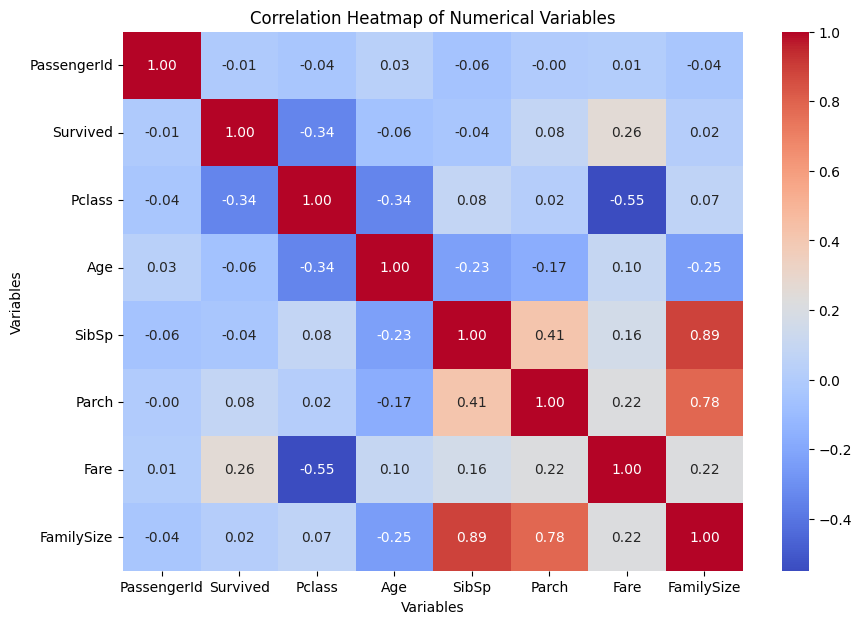

In [28]:
# Requirement 11: Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

+1

Strong positive relationship.

When one increases, the other tends to increase.

0

Little or no linear relationship.

-1

Strong negative relationship.

When one increases, the other tends to decrease.

In your Titanic data, for example:

Pclass and Fare have a noticeable negative correlation.
SibSp and FamilySize have a strong positive relationship.
Pclass and Survived have a negative relationship.

Remember: correlation does not prove causation.


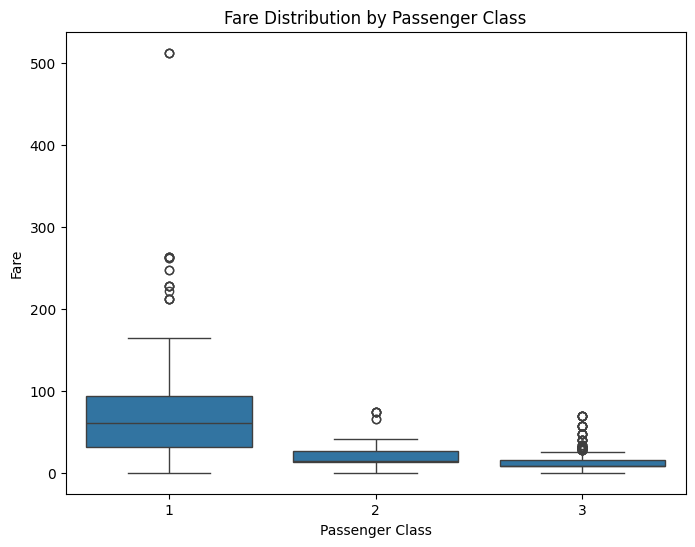

In [29]:
# Requirement 12: Boxplot grouped by category
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

What is a boxplot?

A boxplot helps us see:

median
lower quartile
upper quartile
spread
unusual/outlier observations

You'll notice some very high fares, especially in higher classes.

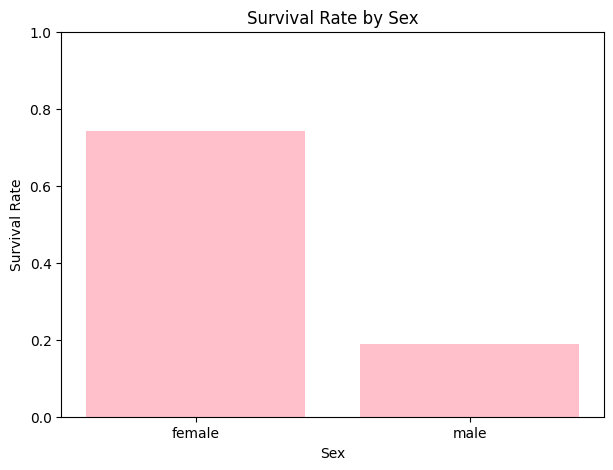

In [30]:
# Requirement 13: Matplotlib chart
survival_rates = df.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(7, 5))
plt.bar(
    survival_rates.index,
    survival_rates.values,
    color="pink"
)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

### Interpretation

The chart shows a substantial difference in survival rates between male and female
passengers in this dataset. The survival rate for female passengers was approximately
74%, while the survival rate for male passengers was approximately 19%. This shows
that sex is strongly associated with survival in the Titanic dataset, although this
analysis alone does not establish causation.


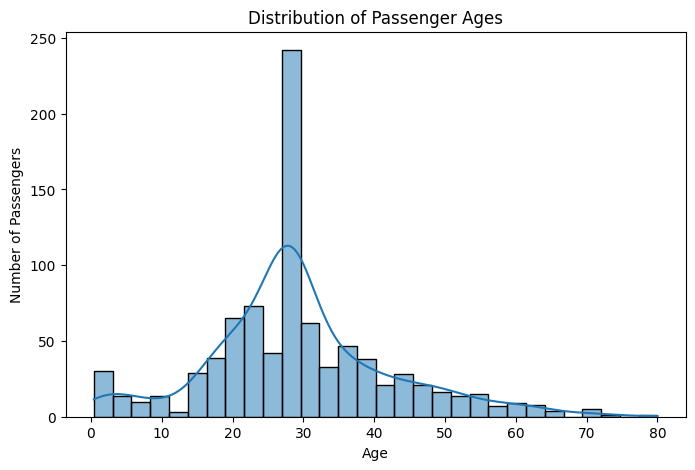

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### Interpretation

The histogram shows the distribution of passenger ages. Most passengers were
concentrated around young and middle adulthood, while relatively fewer passengers
were children or older adults. The distribution is not perfectly symmetrical,
showing that passenger ages varied considerably.

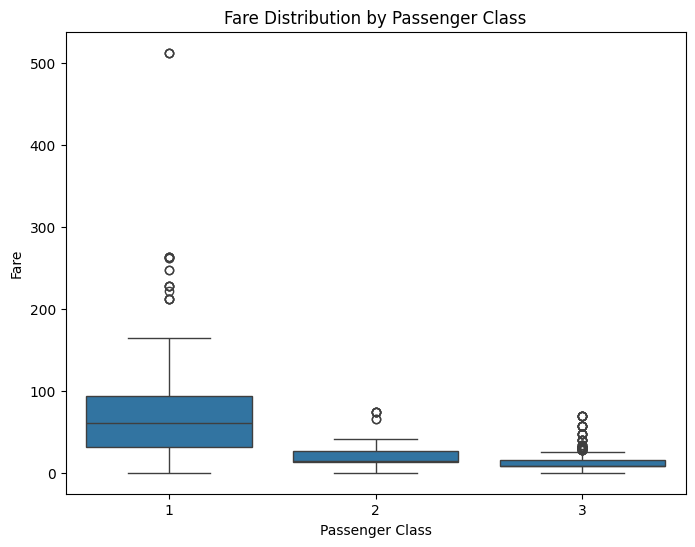

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

### Interpretation

The boxplot shows that passengers in Class 1 generally paid higher fares than
passengers in Classes 2 and 3. Class 1 also has several high-fare observations,
including some clear outliers. This indicates substantial differences in ticket
prices between passenger classes.

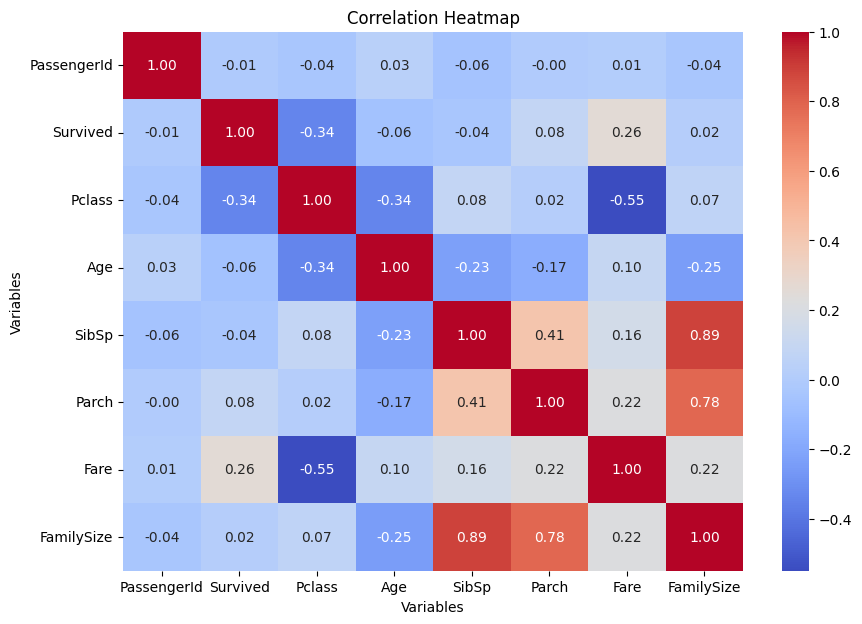

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

### Interpretation

The heatmap shows the linear relationships among the numerical variables.
Passenger class and fare have a noticeable negative correlation, meaning that
higher class numbers, which represent lower passenger classes, are generally
associated with lower fares. Family-related variables such as SibSp and FamilySize
show a strong positive relationship because FamilySize is calculated partly from
SibSp.

Survival by passenger class chart

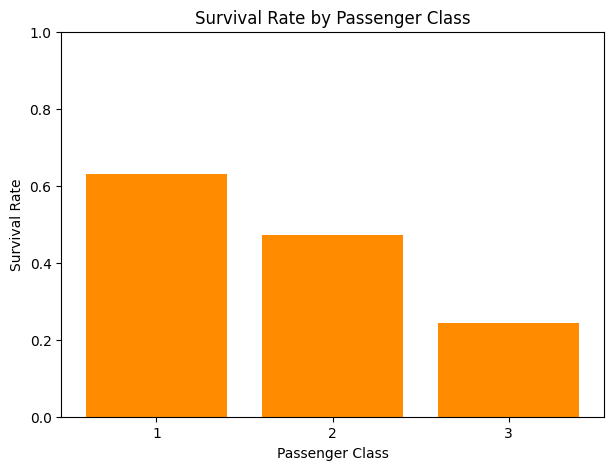

In [34]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
plt.figure(figsize=(7, 5))
plt.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values,
    color="darkorange"
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

### Interpretation

The chart shows that survival rates differed across passenger classes.
Passengers in Class 1 had a higher survival proportion than passengers in
Classes 2 and 3 in this dataset. This indicates that passenger class was
associated with survival during the Titanic disaster.

In [35]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896


In [36]:
upper_limit = Q3 + 1.5 * IQR
print("Upper outlier limit:", upper_limit)

Upper outlier limit: 65.6344


In [37]:
upper_limit = Q3 + 1.5 * IQR
print("Upper outlier limit:", upper_limit)

Upper outlier limit: 65.6344


Group survival by AgeGroup

In [38]:
age_group_survival = (
    df.groupby("AgeGroup")["Survived"]
    .mean()
)
print(age_group_survival)

AgeGroup
Adult          0.417763
Child          0.539823
Senior         0.269231
Young Adult    0.328125
Name: Survived, dtype: float64


Create a chart for AgeGroup

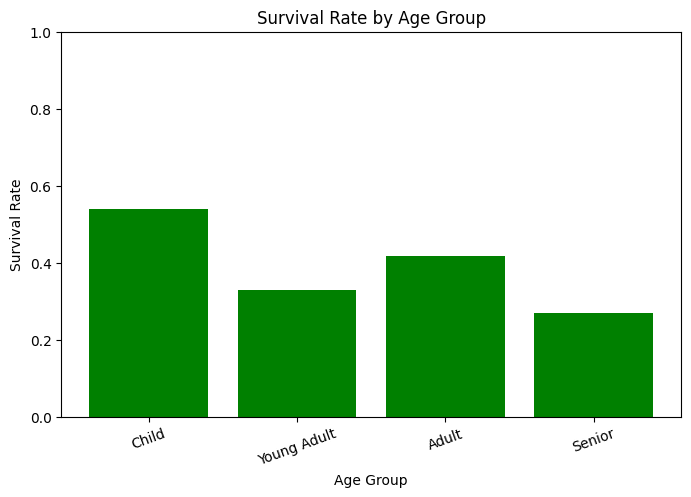

In [40]:
age_group_survival = age_group_survival.reindex(
    ["Child", "Young Adult", "Adult", "Senior"]
)
plt.figure(figsize=(8, 5))
plt.bar(
    age_group_survival.index,
    age_group_survival.values,
    color="green"
)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [42]:
class_lookup = pd.DataFrame({
    "Pclass": [1, 2, 3],
    "ClassName": ["First Class", "Second Class", "Third Class"]
})
print(class_lookup)

   Pclass     ClassName
0       1   First Class
1       2  Second Class
2       3   Third Class


In [43]:
df = df.merge(
    class_lookup,
    on="Pclass",
    how="left"
)
print(df[["Pclass", "ClassName"]].head())

   Pclass    ClassName
0       3  Third Class
1       1  First Class
2       3  Third Class
3       1  First Class
4       3  Third Class


List comprehension

In [45]:
# Requirement 15: List comprehension
df.columns = [column.strip() for column in df.columns]
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'AgeGroup', 'FamilySize', 'FamilyCategory', 'FareLevel', 'ClassName']


Check your final dataset

In [49]:
print(df.shape)
print(df.head())
print(df.isna().sum())

(891, 16)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked     AgeGroup  FamilySize  \
0      0         A/5 21171   7.2500        S  Young Adult           2   
1      0          PC 17599  71.2833        C        Adult           2   
2      0  STON/O2. 3101282   7.9250        S  Young Adult           1   
3      0          

Survival overall

In [50]:
overall_survival = df["Survived"].mean()
print("Overall survival rate:", overall_survival)

Overall survival rate: 0.3838383838383838


Survival by sex

In [51]:
print(
    df.groupby("Sex")["Survived"]
      .mean()
      .sort_values(ascending=False)
)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


Survival by class

In [52]:
print(
    df.groupby("Pclass")["Survived"]
      .mean()
)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Average fare by class

In [53]:
print(
    df.groupby("Pclass")["Fare"]
      .mean()
)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


## Question 1: Did passenger sex affect survival rates?

The Titanic dataset shows a substantial difference in survival rates between
female and male passengers. Approximately 74.2% of female passengers survived,
compared with approximately 18.9% of male passengers. Therefore, sex was strongly
associated with survival in this dataset. However, this descriptive analysis does
not establish that sex itself caused the difference.

## Question 2: Did passenger class affect survival and fare?

Passenger class was associated with both fare and survival in this dataset.
First-class passengers paid substantially higher average fares than second- and
third-class passengers. Survival proportions also differed across passenger
classes, with first-class passengers having a higher survival proportion than
lower-class passengers. These findings describe relationships in the dataset and
do not by themselves establish causation.

## Question 3: How are age, fare, and other numerical variables related?

The correlation analysis shows different levels of relationships among the
numerical variables. Fare and passenger class have a noticeable negative
correlation, while SibSp and FamilySize have a strong positive correlation because
FamilySize is calculated using SibSp and Parch. The correlation between Age and
Survived is relatively weak compared with some of the other relationships.
Correlation describes linear association and does not prove causation.

# Conclusions

This exploratory data analysis examined the Titanic passenger dataset to
understand relationships between passenger characteristics and survival.

First, sex showed a substantial association with survival. Female passengers had
a considerably higher survival proportion than male passengers in this dataset.

Second, passenger class was associated with both fare and survival. First-class
passengers generally paid higher fares and had a higher survival proportion than
passengers in the lower classes.

Third, the correlation analysis revealed relationships among numerical variables,
including a noticeable negative relationship between passenger class and fare and
a strong positive relationship between family-related variables.

The analysis also identified missing values and potential fare outliers. Missing
ages were replaced with the median, missing embarkation values were replaced with
the mode, and the Cabin column was removed because it contained a very large
number of missing values.

Overall, the EDA demonstrates how Python can be used to load, clean, transform,
analyze, visualize, and interpret a real-world dataset. The findings describe
patterns present in this dataset but should not be interpreted as proof of causal
relationships.

TITLE
1. Project Overview

 2. Dataset Source

 3. Research Questions

 4. Import Libraries

 5. Load Dataset
 6. Initial Inspection
     ├── shape
     ├── head
     ├── info
     └── describe

 7. Identify Data Types

 8. Missing Values

 9. Data Cleaning
   ├── Age
   ├── Embarked
   └── Cabin
 10. Feature Engineering
     ├── AgeGroup
     ├── FamilySize
     ├── FamilyCategory
     └── FareLevel

 11. Filtering

 12. Sorting

 13. GroupBy Analysis

 14. Multiple Aggregation

 15. Reindexing

 16. Outlier Detection

 17. Correlation Analysis

 18. Visualization
     ├── Chart 1: Survival by Sex
     ├── Chart 2: Age Distribution
     ├── Chart 3: Fare by Class
     ├── Chart 4: Correlation Heatmap
     └── Chart 5: Survival by Class

 19. Conclusions

 20. Requirements Checklist